EXPLORATORY DATA ANALYSIS

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

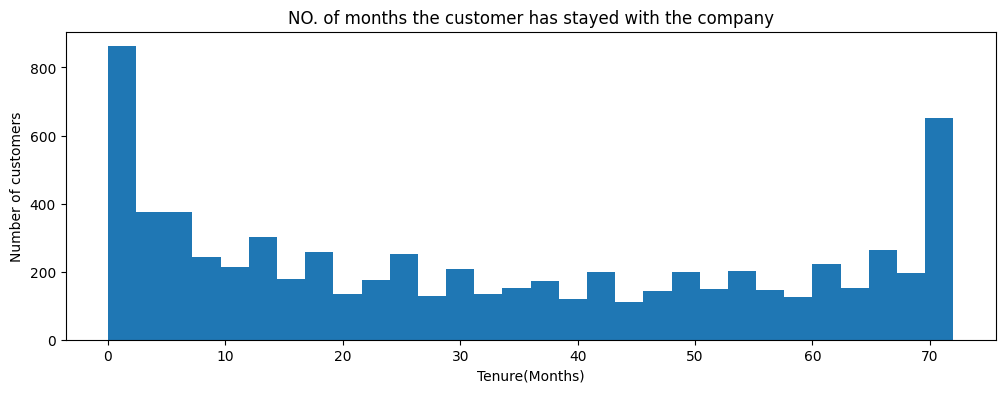

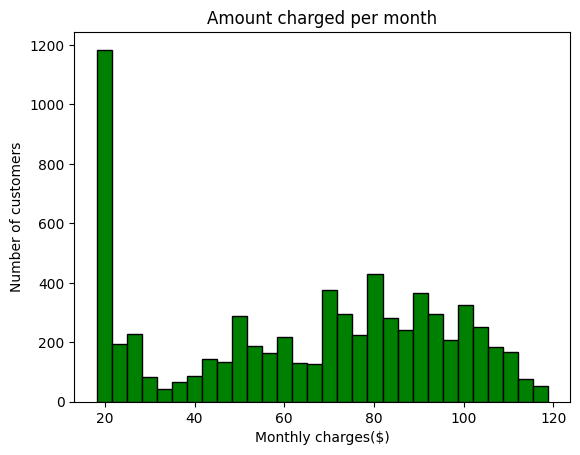

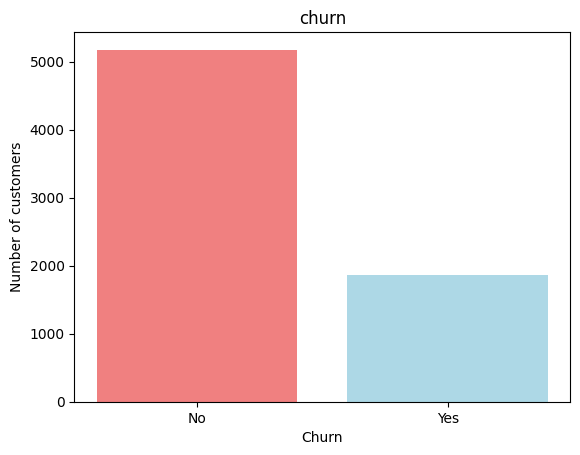

Contract distribution

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
Internet service distribution

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Payment method distribution

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64
Senior citizen proportion
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Senior citizens (1): 1142 customers (16.2%)
Non-seniors (0): 5901 customers (83.8%)



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#load data
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
#getting info
print(df_raw.head())
print(df_raw.dtypes)
print(df_raw.isnull().sum())

print("\nStatistical summary")
print(df_raw.describe())
#Check distribution of tenure
plt.figure(figsize=(12,4))
plt.hist(df_raw['tenure'], bins=30)
plt.title("NO. of months the customer has stayed with the company")
plt.xlabel("Tenure(Months)")
plt.ylabel("Number of customers")
plt.show()

#Distribution of monthly charges
plt.hist(df_raw['MonthlyCharges'], bins=30, edgecolor='black', color='green')
plt.xlabel("Monthly charges($)")
plt.ylabel("Number of customers")
plt.title("Amount charged per month")
plt.show()

#Churn proportion
churn_counts = df_raw['Churn'].value_counts()
plt.bar(churn_counts.index, churn_counts.values, color=['lightcoral', 'lightblue'])
plt.xlabel('Churn')
plt.ylabel('Number of customers')
plt.title("churn")
plt.show()

#contract types
print("Contract distribution\n")
print(df_raw['Contract'].value_counts())

print("Internet service distribution\n")
print(df_raw['InternetService'].value_counts())

print("Payment method distribution\n")
print(df_raw['PaymentMethod'].value_counts())

print("Senior citizen proportion")
print(df_raw['SeniorCitizen'].value_counts())
senior_count = df_raw['SeniorCitizen'].value_counts()
print(f"Senior citizens (1): {senior_count.get(1,0)} customers ({senior_count.get(1,0)/len(df_raw)*100:.1f}%)")
print(f"Non-seniors (0): {senior_count[0]} customers ({senior_count[0]/len(df_raw)*100:.1f}%)\n")


DATA PREPARATION

In [5]:
from sklearn.preprocessing import StandardScaler

# 1. Make a copy of the raw data to work on
df = df_raw.copy()
print("Original shape: ", df.shape)

#2. Drop customerID column
df = df.drop('customerID', axis=1)
print("After dropping customerID ", df.shape)

#3. Save the churn column for later
churn_labels = df['Churn'].copy()

#4. Dataframe for clustering by dropping the churn column
df_cluster = df.drop('Churn', axis=1).copy()


print(df.dtypes)
#5. Fixing the TotalCharge column 
df_cluster['TotalCharges'] = pd.to_numeric(df_cluster['TotalCharges'], errors='coerce')
median_total = df_cluster['TotalCharges'].median()
df_cluster['TotalCharges'] = df_cluster['TotalCharges'].fillna(median_total)
print("TotalCharges fixed. Missing values now:", df_cluster['TotalCharges'].isnull().sum())

#6. Encode binary columns(Yes/No) as 0 and 1
binary_col = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_col:
    if col == 'gender':
        df_cluster[col] = df_cluster[col].map({'Female':0, 'Male':1})
    else:
        df_cluster[col] = df_cluster[col].map({'Yes':1,'No':0})
    print(f"{col}: Unique values = {df_cluster[col].unique()}, missing = {df_cluster[col].isnull().sum()}")

#7. One-hot encode multi-category 
#These columns have more than 2 possible values( internetservice: DSL, fibreoptic, No)
#One-hot encoding creates a new 0/1 column for each option, except one(To avoid redundancy)
#E.G internetservice becomes two columns: Internet service_Fiber optic and internetService_No
#If both are 0 it means DSL

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']
df_encoded = pd.get_dummies(df_cluster, columns=multi_cat_cols, drop_first=True)
print("Shape after one-hot encoding: ", df_encoded.shape)


#8. Feature engineering: create a column "AvgMonthlyCharges"
#TotalCharges is the sum of all monthly charges over the tenure.
#Dividing by tenure gives the average monthly charge over the customer's lifetime.
#This can be more informative than raw TotalCharges because it adjusts for different tenures.
#We add a tiny number (1e-9) to tenure to avoid division by zero for customers with tenure = 0

df_encoded['AvgMonthlyCharges'] = df_encoded['TotalCharges'] / (df_encoded['tenure'] + 1e-9)

#9. Verify that all columns are numeric(no 'object' type)
print(df_encoded.dtypes)

#10. Scale all numeric features
#Scaling - features have different units and ranges(Tenure 0-72, MonthlyCharges, 18-118 etc)
#Standard scaler transforms each feature tto have mean = 0 and standard deviation = 1

scaler = StandardScaler()
df_encoded = df_encoded.replace([np.inf, -np.inf], np.nan)
df_encoded = df_encoded.fillna(df_encoded.mean())
df_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)
print("\nScaled data", df_scaled)
print("\nMean of each scaled column")
print(df_scaled.mean())

Original shape:  (7043, 21)
After dropping customerID  (7043, 20)
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
TotalCharges fixed. Missing values now: 0
gender: Unique values = [0 1], missing = 0
Partner: Unique values = [1 0], missing = 0
Dependents: Unique values = [0 1], missing = 0
PhoneService: Unique values = [0 1], missing = 0
PaperlessBilling: Unique values = [1 0], missing = 0
Shape after one-hot encoding:  (7043, 30)
gender                                  

Phase 2 – PCA (Principal Component Analysis) reducing the many features we have(from 30 to a smaller number)

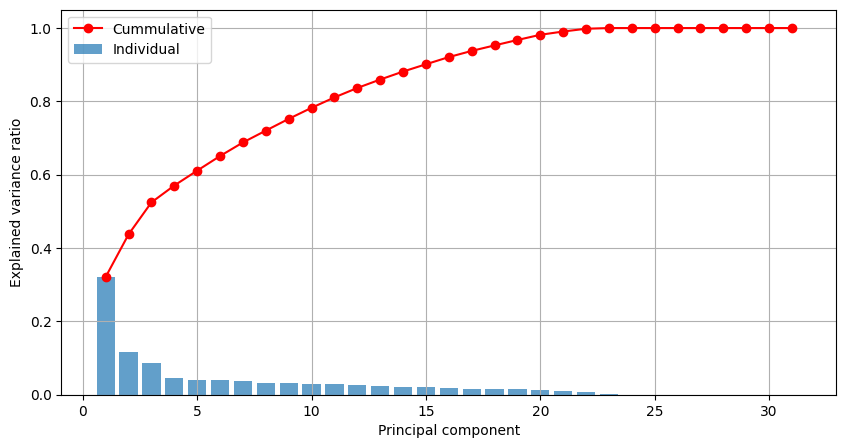

Number of components to keep (85% variance): 13
Shape after PCA reduction:  (7043, 13)
k=2: silhoutte score = 0.3908
k=3: silhoutte score = 0.2516
k=4: silhoutte score = 0.2778
k=5: silhoutte score = 0.2336
k=6: silhoutte score = 0.2296
k=7: silhoutte score = 0.2331
k=8: silhoutte score = 0.1785
k=9: silhoutte score = 0.1725
k=10: silhoutte score = 0.1786

Best number of clusters: 2 (silhoutte = 0.3908)


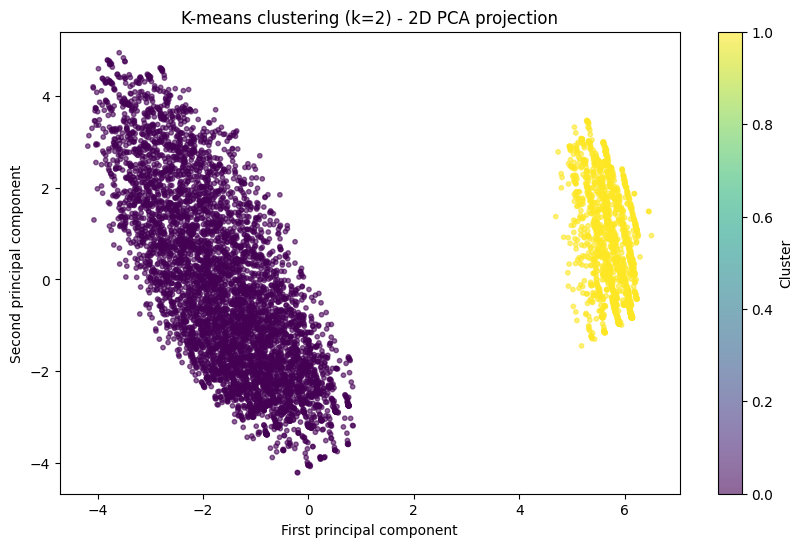

In [6]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

#1. fit PCA on the scaled data
pca = PCA()
pca.fit(df_scaled)

#Explained variance ration (how much variance each component has)
#Returns an array of percntages representing the proportion of the datasets total information captured by that specific component
explained_variance = pca.explained_variance_ratio_
#Shows the total percentage of information you retain as you add more components
cummulative_variance = np.cumsum(explained_variance)

#Scree plt: individual and cummalative explained variance
plt.figure(figsize=(10,5))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, label='Individual')
plt.plot(range(1, len(explained_variance)+1), cummulative_variance, 'ro-', label='Cummulative')
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.legend()
plt.grid(True)
plt.show()

#Choose number of components that explain at least 85% variance
#argmax() - returns the index of the highest value in an array
n_components = (cummulative_variance >= 0.85).argmax() + 1
print(f"Number of components to keep (85% variance): {n_components}")

#reduce the data
pca_reduced = PCA(n_components=n_components)
df_pca = pca_reduced.fit_transform(df_scaled)
print("Shape after PCA reduction: ", df_pca.shape)


#2. Determine the best number of clusters using silhoutte score
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhoutte score = {score:.4f}")

#best k is the one with highest silhoutte score
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nBest number of clusters: {best_k} (silhoutte = {max(silhouette_scores):.4f})")


#3. Run k-means with the best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_pca)

#4. visualise clusters in 2D using the first two principal components
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(df_pca_2d[:,0], df_pca_2d[:,1], c=cluster_labels, cmap='viridis',s=10, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title(f"K-means clustering (k={best_k}) - 2D PCA projection")
plt.show()


Phase 3: Cluster Profiling – Understand what each cluster means

In [15]:
import pandas as pd

df_encoded['Cluster'] = cluster_labels

#1. summary statistics for numeric columns per cluster
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges','AvgMonthlyCharges']
cluster_summary = df_encoded.groupby('Cluster')[numeric_cols].mean()
print("Numeric feature averages per cluster")
print(cluster_summary.round(2),"\n")

#2. categorical feature proportions per cluster
#select categorical columns that were one-hot encoded(those with 'bool' type)
categorical_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()
binary_col = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling']
all_cat_col = binary_col + categorical_cols

#For each cluster, we need the proportion of customers with value = 1 or True
cat_proportions = df_encoded.groupby('Cluster')[all_cat_col].mean()
print(cat_proportions.round(3))

#3. check churn per cluster
df_encoded_with_churn = df_encoded.copy()
df_encoded_with_churn['Churn'] = churn_labels.values

#churn rate per cluster
churn_rate = df_encoded_with_churn.groupby('Cluster')['Churn'].apply(lambda x:(x=='Yes').mean())
print("Churn rate per cluster (validation)")
print(churn_rate.round(3))

Numeric feature averages per cluster
         tenure  MonthlyCharges  TotalCharges  AvgMonthlyCharges
Cluster                                                         
0         32.88           76.84        2728.3       1.266517e+09
1         30.55           21.08         668.1       5.494659e+09 

         gender  SeniorCitizen  Partner  Dependents  PhoneService  \
Cluster                                                             
0         0.503          0.198    0.483       0.266         0.876   
1         0.510          0.034    0.484       0.421         1.000   

         PaperlessBilling  MultipleLines_No phone service  MultipleLines_Yes  \
Cluster                                                                        
0                   0.675                           0.124              0.477   
1                   0.292                           0.000              0.224   

         InternetService_Fiber optic  InternetService_No  ...  \
Cluster                               

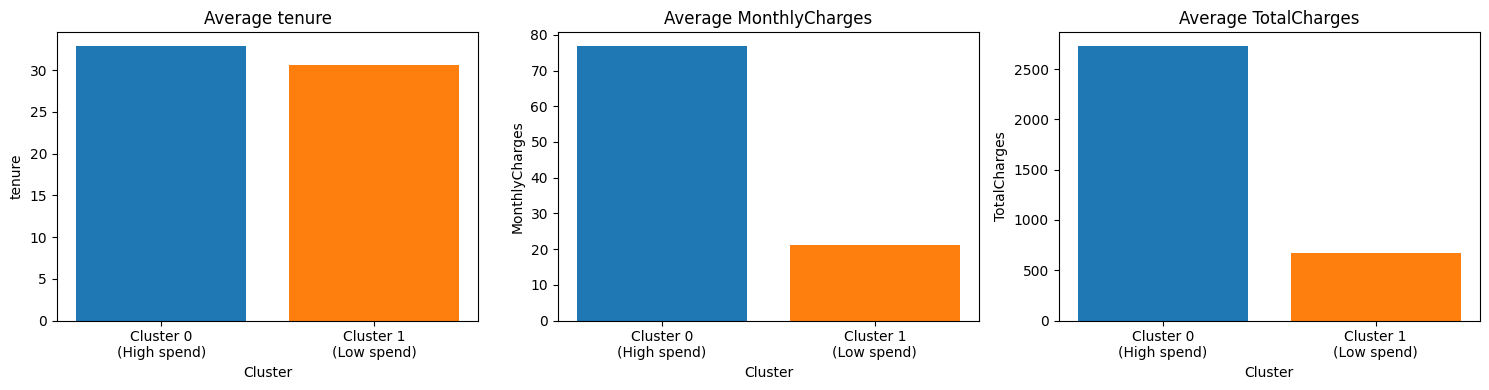

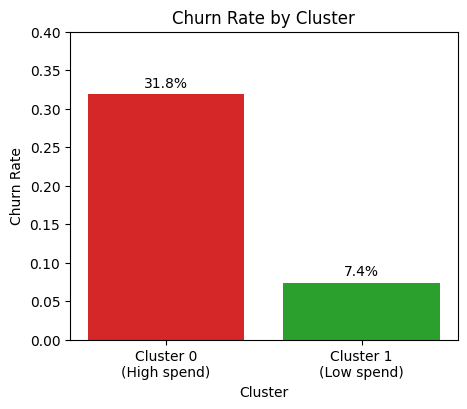

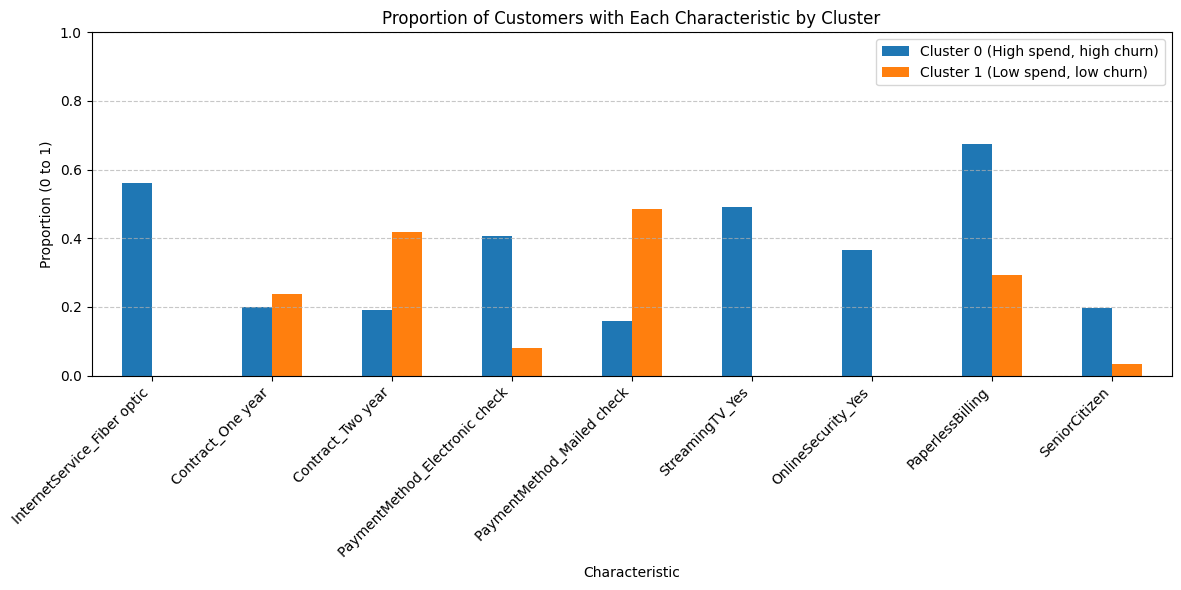

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare numeric data (ignore broken AvgMonthlyCharges)
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
numeric_means = cluster_summary[numeric_features]  # from your earlier calculation

# Plot numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(numeric_features):
    axes[i].bar(numeric_means.index, numeric_means[feat], color=['#1f77b4', '#ff7f0e'])
    axes[i].set_title(f'Average {feat}')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Cluster 0\n(High spend)', 'Cluster 1\n(Low spend)'])
plt.tight_layout()
plt.show()

# Plot churn rate
churn_rate_plot = churn_rate  # from your validation
plt.figure(figsize=(5,4))
plt.bar(churn_rate_plot.index, churn_rate_plot.values, color=['#d62728', '#2ca02c'])
plt.title('Churn Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate')
plt.ylim(0, 0.4)
plt.xticks([0,1], ['Cluster 0\n(High spend)', 'Cluster 1\n(Low spend)'])
for i, v in enumerate(churn_rate_plot.values):
    plt.text(i, v + 0.01, f"{v:.1%}", ha='center')
plt.show()

# Select key categorical features to compare
key_cat = [
    'InternetService_Fiber optic',
    'Contract_One year', 'Contract_Two year',
    'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
    'StreamingTV_Yes', 'OnlineSecurity_Yes',
    'PaperlessBilling', 'SeniorCitizen'
]

# Extract proportions for clusters
cat_compare = cat_proportions[key_cat]  # from your earlier calculation

# Plot as grouped bar chart
cat_compare.T.plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Proportion of Customers with Each Characteristic by Cluster')
plt.xlabel('Characteristic')
plt.ylabel('Proportion (0 to 1)')
plt.legend(['Cluster 0 (High spend, high churn)', 'Cluster 1 (Low spend, low churn)'])
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Supervised churn prediction

In [28]:
# Fix AvgMonthlyCharges: for tenure=0, use MonthlyCharges, otherwise TotalCharges/tenure
df_encoded['AvgMonthlyCharges'] = df_encoded['MonthlyCharges'].copy()
mask = df_encoded['tenure'] > 0
df_encoded.loc[mask, 'AvgMonthlyCharges'] = df_encoded.loc[mask, 'TotalCharges'] / df_encoded.loc[mask, 'tenure']

# Replace any infinity or NaN that might have appeared (just in case)
df_encoded = df_encoded.replace([np.inf, -np.inf], np.nan).fillna(df_encoded.mean())

prepare features(X) and target(y)

In [29]:
X = df_encoded.copy()
y = (churn_labels == 'Yes').astype(int)

print("feature shape: ", X.shape)
print("Churn rate: {:.2f}%".format(y.mean()*100))

feature shape:  (7043, 32)
Churn rate: 26.54%


3. Split data into training and testing sets

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42, stratify=y)
print("Train size: ", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size:  5634
Test size:  1409


4. Scale numeric features

In [32]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns (the ones that are not binary/boolean)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharges']
# All other columns are already 0/1 (binary or one‑hot)
binary_cols = [c for c in X.columns if c not in numeric_cols]

# Scale only the numeric columns
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_numeric_scaled = scaler.transform(X_test[numeric_cols])

# Combine scaled numeric with unchanged binary columns
import numpy as np
X_train_final = np.hstack([X_train_numeric_scaled, X_train[binary_cols].values])
X_test_final = np.hstack([X_test_numeric_scaled, X_test[binary_cols].values])

print("Final training feature shape:", X_train_final.shape)

Final training feature shape: (5634, 32)


Train 3 models: LOGISTIC REGRESSION, RANDOM FOREST, XGBOOST

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Dictionary to store results
results = {}

# ---- Logistic Regression ----
print("\n--- Logistic Regression ---")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_final, y_train)
y_pred_log = log_reg.predict(X_test_final)
y_proba_log = log_reg.predict_proba(X_test_final)[:, 1]

results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision (churn)': precision_score(y_test, y_pred_log, pos_label=1),
    'Recall (churn)': recall_score(y_test, y_pred_log, pos_label=1),
    'F1 (churn)': f1_score(y_test, y_pred_log, pos_label=1),
    'ROC AUC': roc_auc_score(y_test, y_proba_log)
}
print(f"ROC AUC: {results['Logistic Regression']['ROC AUC']:.4f}")

# ---- Random Forest ----
print("\n--- Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_final, y_train)
y_pred_rf = rf.predict(X_test_final)
y_proba_rf = rf.predict_proba(X_test_final)[:, 1]

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision (churn)': precision_score(y_test, y_pred_rf, pos_label=1),
    'Recall (churn)': recall_score(y_test, y_pred_rf, pos_label=1),
    'F1 (churn)': f1_score(y_test, y_pred_rf, pos_label=1),
    'ROC AUC': roc_auc_score(y_test, y_proba_rf)
}
print(f"ROC AUC: {results['Random Forest']['ROC AUC']:.4f}")

# ---- XGBoost ----
print("\n--- XGBoost ---")
xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_final, y_train)
y_pred_xgb = xgb.predict(X_test_final)
y_proba_xgb = xgb.predict_proba(X_test_final)[:, 1]

results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision (churn)': precision_score(y_test, y_pred_xgb, pos_label=1),
    'Recall (churn)': recall_score(y_test, y_pred_xgb, pos_label=1),
    'F1 (churn)': f1_score(y_test, y_pred_xgb, pos_label=1),
    'ROC AUC': roc_auc_score(y_test, y_proba_xgb)
}
print(f"ROC AUC: {results['XGBoost']['ROC AUC']:.4f}")


--- Logistic Regression ---
ROC AUC: 0.8421

--- Random Forest ---
ROC AUC: 0.8230

--- XGBoost ---


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [02:06:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC AUC: 0.8290


Results of the model


=== Model Performance ===
                     Accuracy  Precision (churn)  Recall (churn)  F1 (churn)  \
Logistic Regression    0.8055             0.6572          0.5588      0.6040   
Random Forest          0.7899             0.6327          0.4973      0.5569   
XGBoost                0.7814             0.6031          0.5160      0.5562   

                     ROC AUC  
Logistic Regression   0.8421  
Random Forest         0.8230  
XGBoost               0.8290  


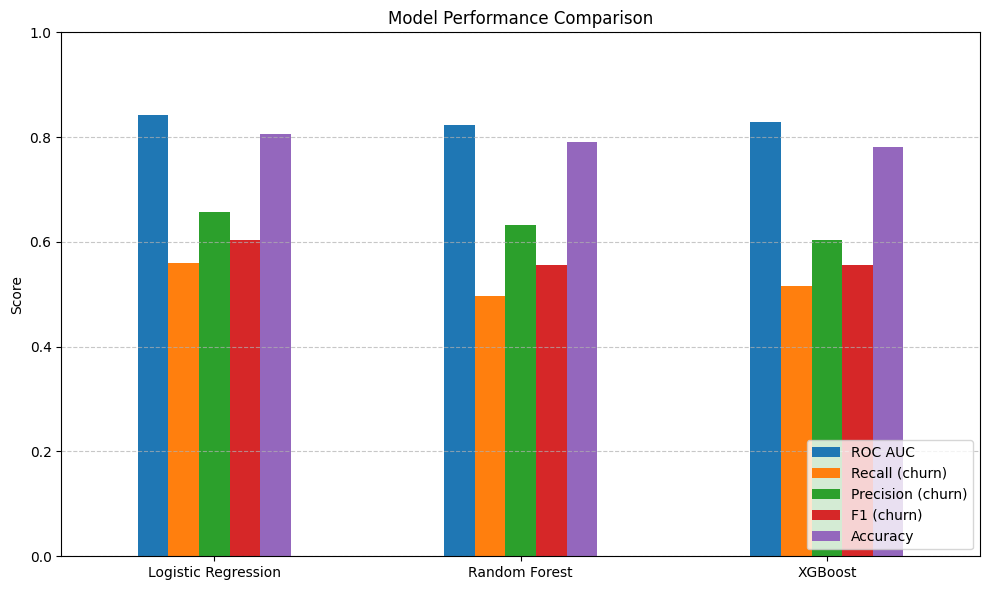

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert results to DataFrame
df_results = pd.DataFrame(results).T
print("\n=== Model Performance ===")
print(df_results.round(4))

# Bar chart comparison
metrics = ['ROC AUC', 'Recall (churn)', 'Precision (churn)', 'F1 (churn)', 'Accuracy']
df_results[metrics].plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()